In [157]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import seaborn as sns

In [117]:
df = pd.read_csv(
    "lcd.csv",
    low_memory=False
)
df["PULMONARY_DISEASE"] = df["PULMONARY_DISEASE"].map({"YES": 1, "NO": 0})
df.shape

(5000, 18)

Tests to show why not changing the dataset is not suitable as is:

In [118]:
df["PULMONARY_DISEASE"].value_counts(normalize=True)

PULMONARY_DISEASE
0    0.5926
1    0.4074
Name: proportion, dtype: float64

In [119]:
X = df.drop(columns=["PULMONARY_DISEASE"])
y = df["PULMONARY_DISEASE"]

print(X.shape)
print(y.value_counts())

(5000, 17)
PULMONARY_DISEASE
0    2963
1    2037
Name: count, dtype: int64


In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [121]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid search
grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

# Best parameters
print("Random Forest Best Params:", grid_rf.best_params_)

# Best model
best_rf = grid_rf.best_estimator_

# Predictions
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest Accuracy: 0.9
Random Forest ROC-AUC: 0.9195679508964816
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       889
           1       0.89      0.86      0.88       611

    accuracy                           0.90      1500
   macro avg       0.90      0.89      0.90      1500
weighted avg       0.90      0.90      0.90      1500



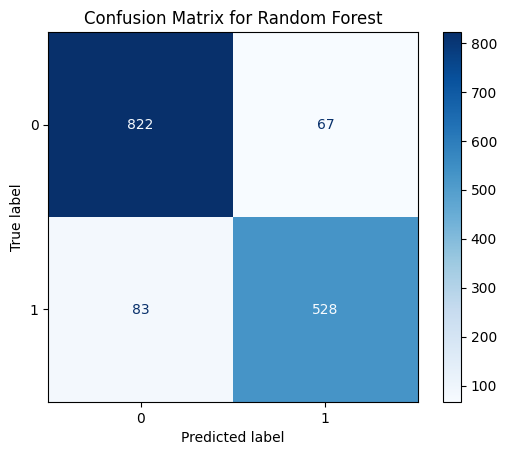

In [122]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Random Forest")
plt.show()

In [123]:
feat_importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feat_importance.head(10))

SMOKING                   0.238438
ENERGY_LEVEL              0.143462
THROAT_DISCOMFORT         0.120438
BREATHING_ISSUE           0.120243
OXYGEN_SATURATION         0.078654
AGE                       0.066576
SMOKING_FAMILY_HISTORY    0.057678
STRESS_IMMUNE             0.036554
EXPOSURE_TO_POLLUTION     0.031182
FAMILY_HISTORY            0.019797
dtype: float64


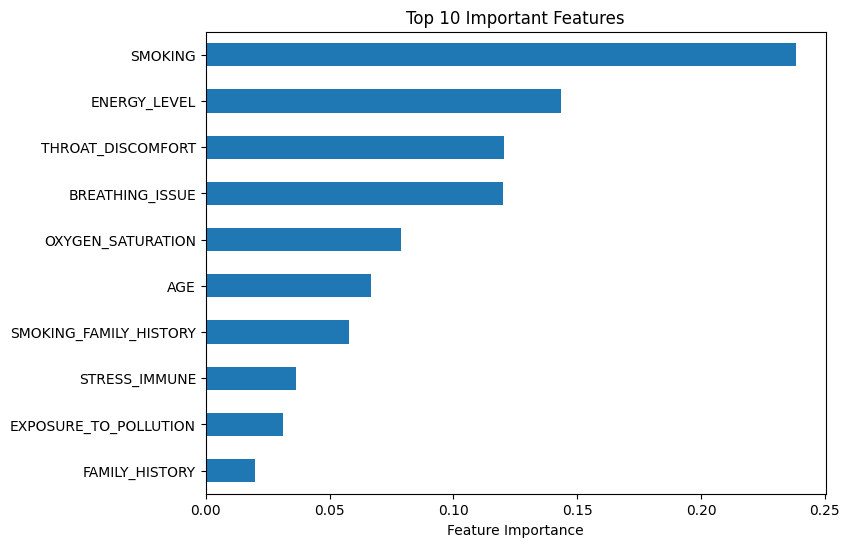

In [124]:
feat_importance.head(10).plot(
    kind="barh",
    figsize=(8,6)
)

plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Feature Importance")
plt.show()

In [125]:
# Train/test split
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y,
    test_size=0.2,
    random_state=4,
    stratify=y
)

# Impute missing values
imputer = SimpleImputer(strategy="most_frequent")
X_train_imp = imputer.fit_transform(X_train1)
X_test_imp = imputer.transform(X_test1)

# Scale
scaler1 = MinMaxScaler()
X_train2 = scaler1.fit_transform(X_train_imp)
X_test2 = scaler1.transform(X_test_imp)

# Logistic regression
lrn = LogisticRegression(max_iter=2000)
lrn.fit(X_train2, y_train1)

# Predict on the SCALED data
y_train_pred1 = lrn.predict(X_train2)
y_pred1 = lrn.predict(X_test2)
y_prob1 = lrn.predict_proba(X_test2)[:, 1]

# Metrics
train_accuracy = accuracy_score(y_train1, y_train_pred1)
test_accuracy = accuracy_score(y_test1, y_pred1)
error = 1 - test_accuracy

print("Logistic Regression training accuracy:", train_accuracy)
print("Logistic Regression test error rate:", error)
print("Logistic Regression accuracy:", test_accuracy)
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test1, y_prob1))
print(classification_report(y_test1, y_pred1))

Logistic Regression training accuracy: 0.89975
Logistic Regression test error rate: 0.10199999999999998
Logistic Regression accuracy: 0.898
Logistic Regression ROC-AUC: 0.9300520818227394
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       593
           1       0.86      0.89      0.88       407

    accuracy                           0.90      1000
   macro avg       0.89      0.90      0.89      1000
weighted avg       0.90      0.90      0.90      1000



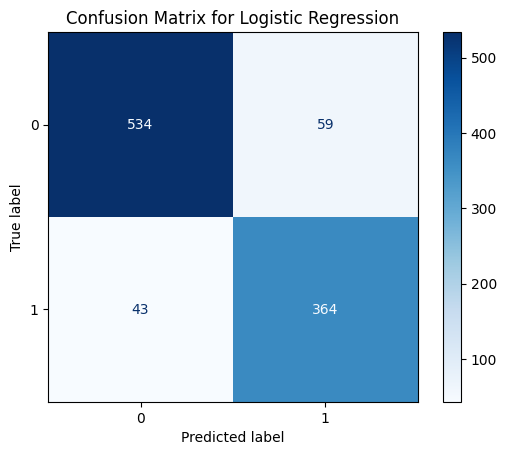

In [126]:
cm = confusion_matrix(y_test1, y_pred1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

In [127]:
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("XGBoost Best Params:", grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Best Params: {'colsample_bytree': 1, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
XGBoost Accuracy: 0.892
XGBoost ROC-AUC: 0.9163406538176181
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       889
           1       0.88      0.86      0.87       611

    accuracy                           0.89      1500
   macro avg       0.89      0.89      0.89      1500
weighted avg       0.89      0.89      0.89      1500



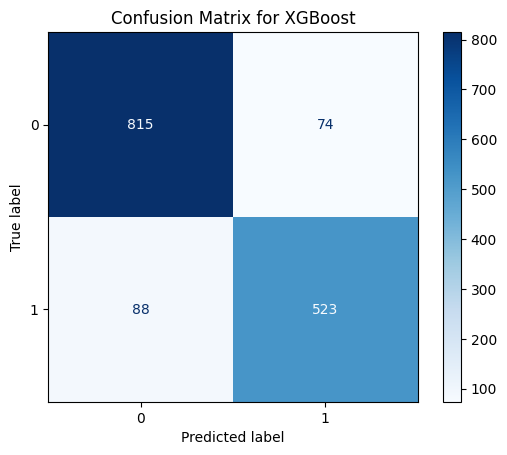

In [128]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for XGBoost")
plt.show()

In [129]:
param_grid_lgbm = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 50, 70],
    "max_depth": [-1, 10, 20]
}

lgbm = LGBMClassifier(random_state=42)

grid_lgbm = GridSearchCV(
    lgbm,
    param_grid_lgbm,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_lgbm.fit(X_train, y_train)

print("LightGBM Best Params:", grid_lgbm.best_params_)

best_lgbm = grid_lgbm.best_estimator_

y_pred_lgbm = best_lgbm.predict(X_test)
y_prob_lgbm = best_lgbm.predict_proba(X_test)[:, 1]

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("LightGBM ROC-AUC:", roc_auc_score(y_test, y_prob_lgbm))
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 1426, number of negative: 2074
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001677 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 594
[LightGBM] [Info] Number of data points in the train set: 3500, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.407429 -> initscore=-0.374606
[LightGBM] [Info] Start training from score -0.374606
LightGBM Best Params: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 50}
LightGBM Accuracy: 0.9033333333333333
LightGBM ROC-AUC: 0.9114766955276254
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       889
           1       0.89      0.88      0.88       611

    accuracy                           0.90      1500
   macro avg       0.90      0.90      0.90      1500
weighted avg       0.90      0.90      0.90      1500



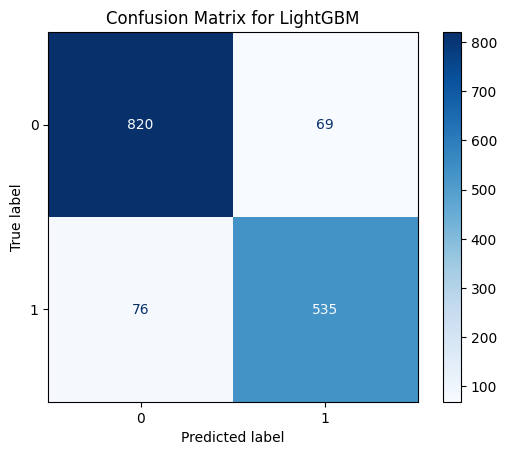

In [130]:
cm = confusion_matrix(y_test, y_pred_lgbm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for LightGBM")
plt.show()

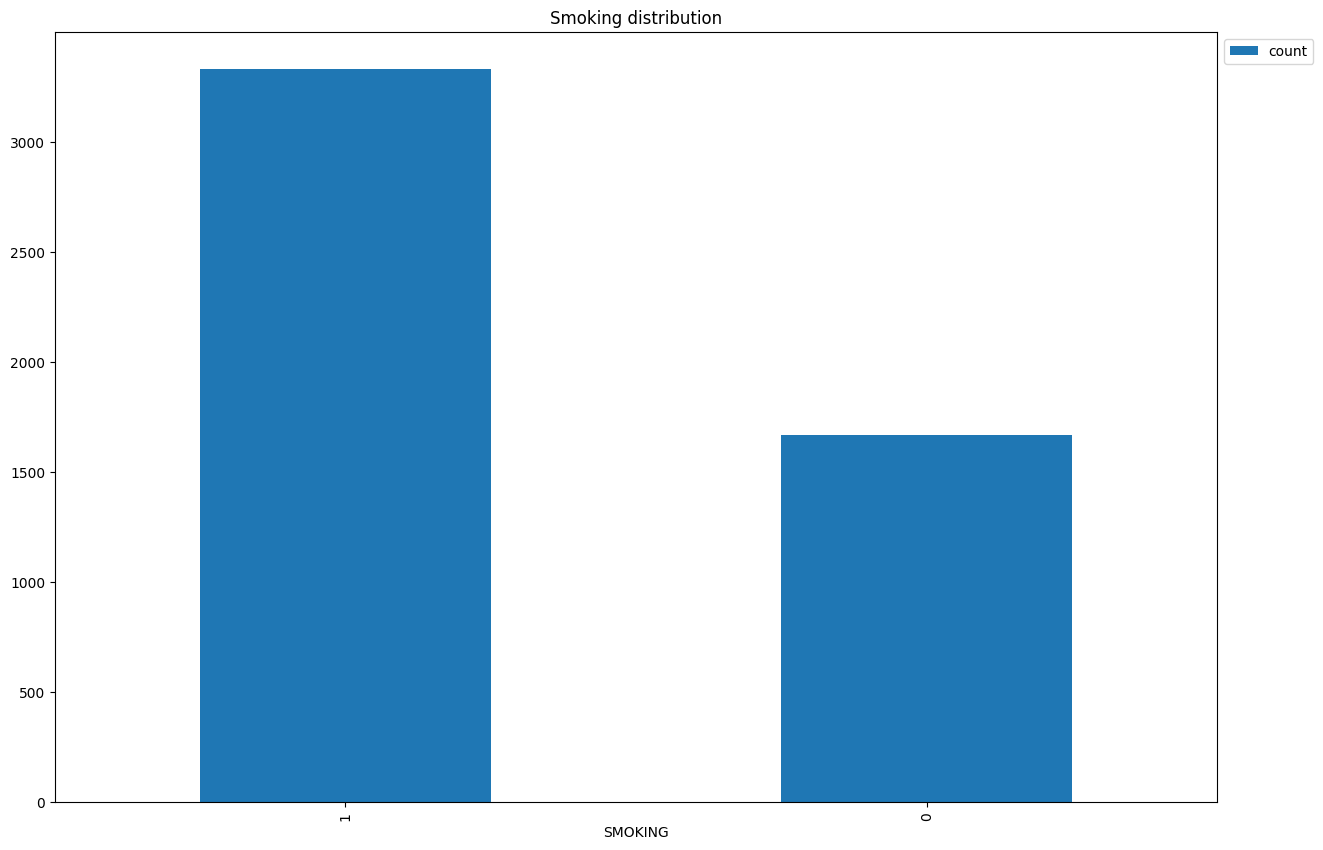

In [131]:
SmokingPlt = X['SMOKING'].value_counts().plot(
    kind='bar',
    title="Smoking distribution",
    figsize=(15,10)
)

SmokingPlt.legend(loc='upper left', bbox_to_anchor=(1,1))

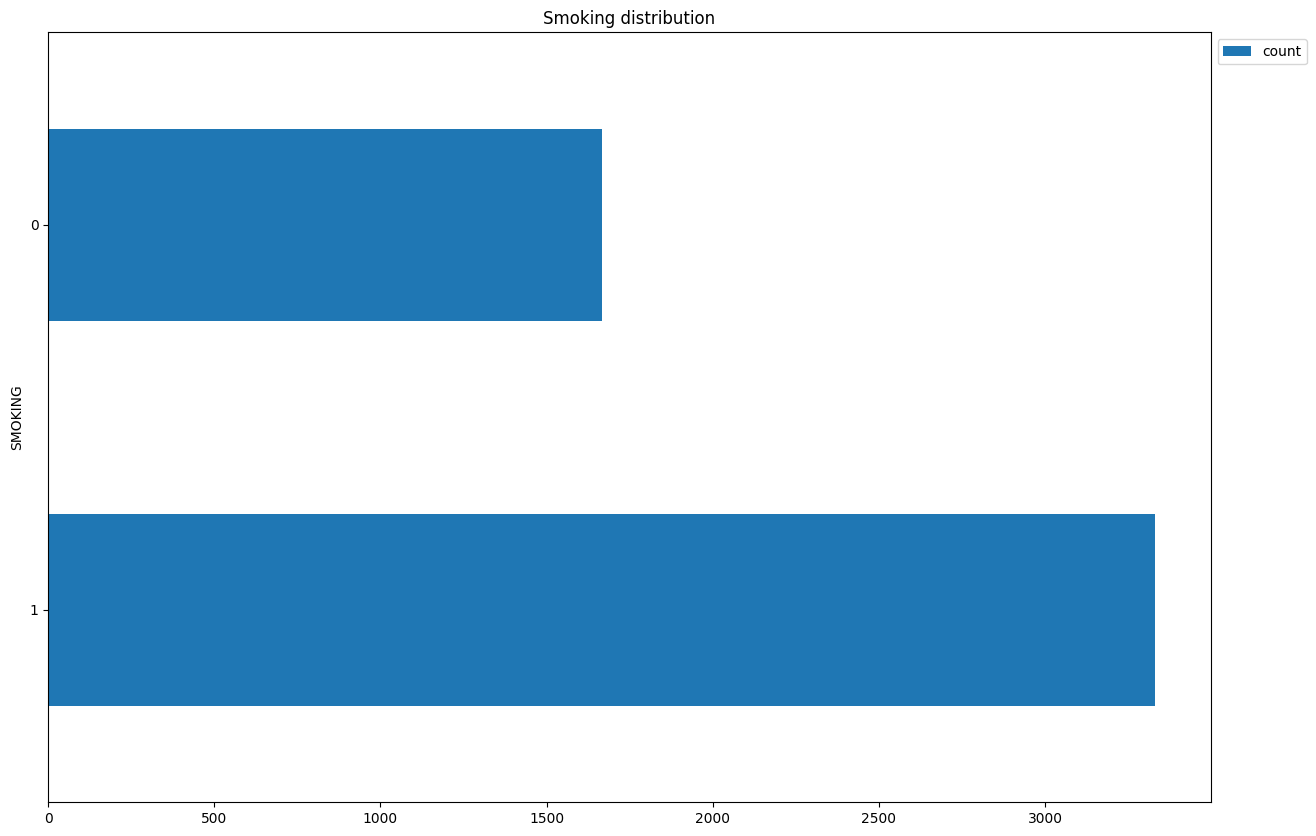

In [132]:
SmokingPlt = X['SMOKING'].value_counts().plot(
    kind='barh',
    title="Smoking distribution",
    figsize=(15,10)
)

SmokingPlt.legend(loc='upper left', bbox_to_anchor=(1,1))

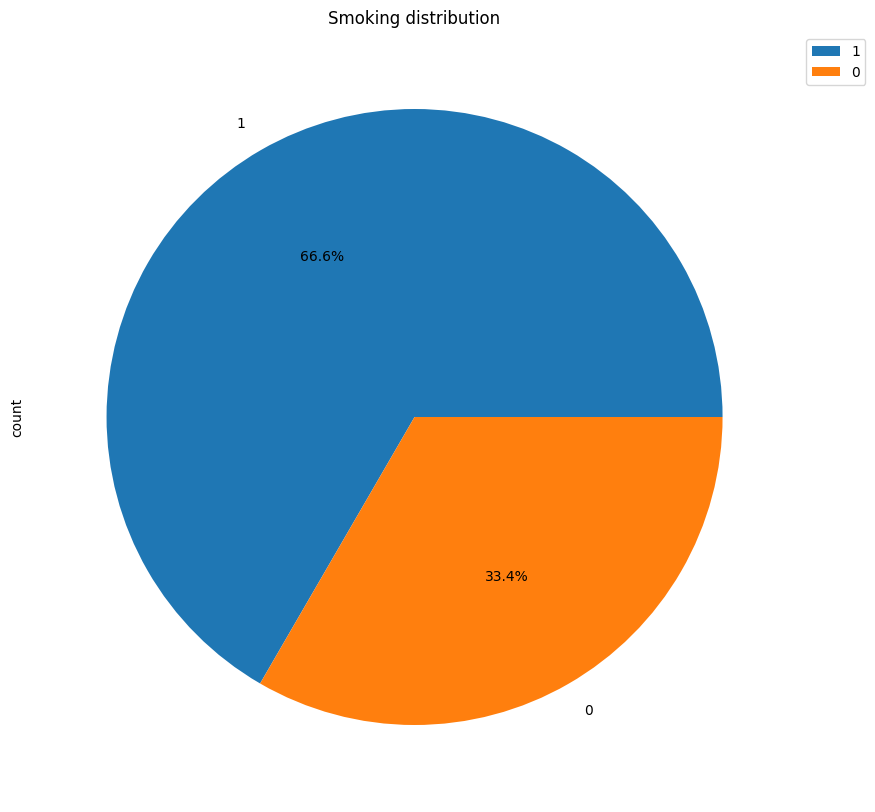

In [133]:
SmokingPlt = X['SMOKING'].value_counts().plot(
    kind='pie',
    title="Smoking distribution",
    autopct='%1.1f%%',
    figsize=(15,10)
)

SmokingPlt.legend(loc='upper left', bbox_to_anchor=(1,1))

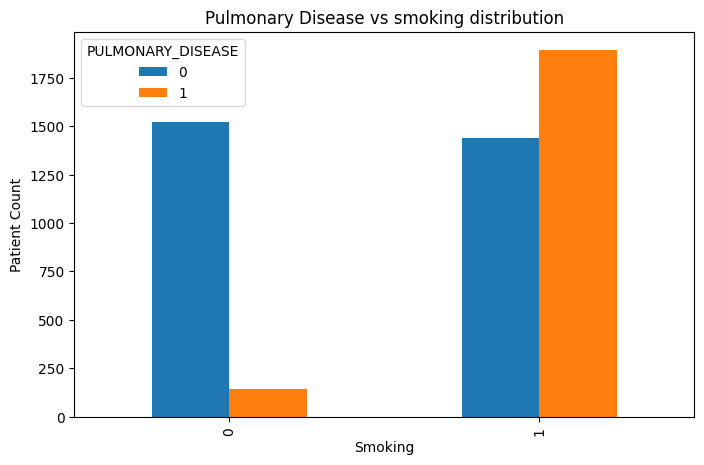

In [134]:
pd.crosstab(
    X['SMOKING'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Pulmonary Disease vs smoking distribution")
plt.xlabel("Smoking")
plt.ylabel("Patient Count")
plt.show()

In [135]:
Q1 = df["OXYGEN_SATURATION"].quantile(0.25)
Q3 = df["OXYGEN_SATURATION"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["OXYGEN_SATURATION"] < Q1 - 1.5*IQR) |
              (df["OXYGEN_SATURATION"] > Q3 + 1.5*IQR)]

print(len(outliers))

30


In [136]:
Q1 = df["ENERGY_LEVEL"].quantile(0.25)
Q3 = df["ENERGY_LEVEL"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["ENERGY_LEVEL"] < Q1 - 1.5*IQR) |
              (df["ENERGY_LEVEL"] > Q3 + 1.5*IQR)]

print(len(outliers))

31


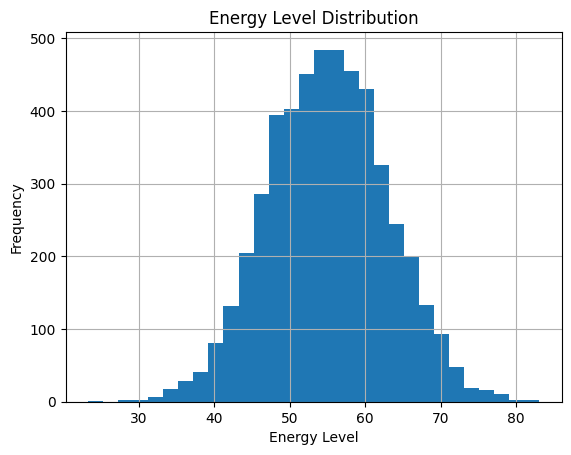

In [137]:
X["ENERGY_LEVEL"].hist(bins=30)
plt.title("Energy Level Distribution")
plt.xlabel("Energy Level")
plt.ylabel("Frequency")
plt.show()

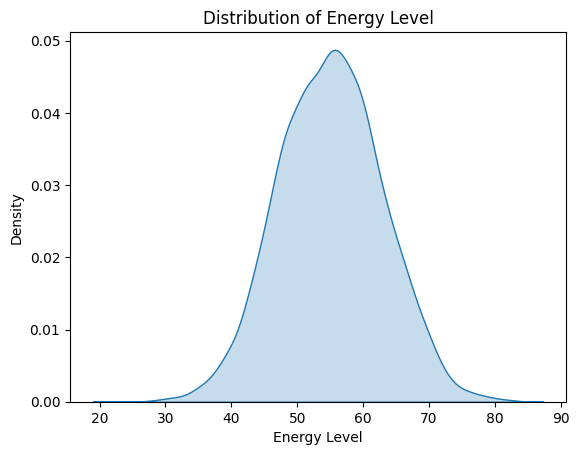

In [138]:
sns.kdeplot(X["ENERGY_LEVEL"], fill=True)
plt.title("Distribution of Energy Level")
plt.xlabel("Energy Level")
plt.ylabel("Density")
plt.show()

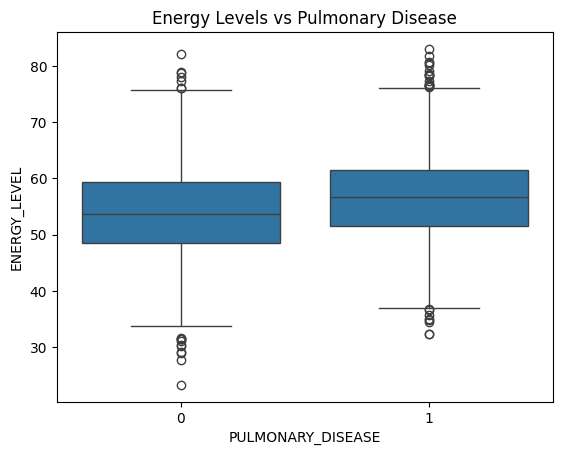

In [139]:
sns.boxplot(x="PULMONARY_DISEASE", y="ENERGY_LEVEL", data=df)
plt.title("Energy Levels vs Pulmonary Disease")
plt.show()

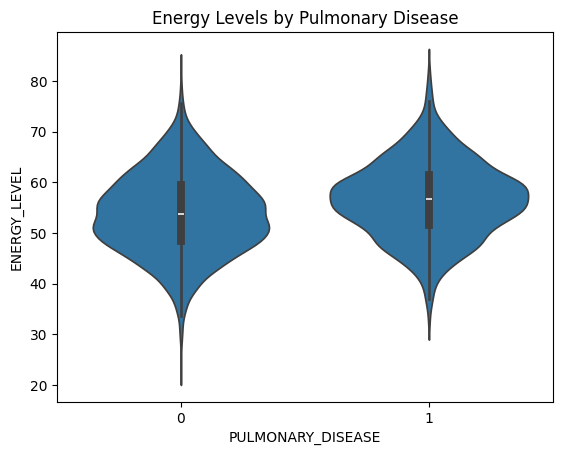

In [140]:
sns.violinplot(x="PULMONARY_DISEASE", y="ENERGY_LEVEL", data=df)
plt.title("Energy Levels by Pulmonary Disease")
plt.show()

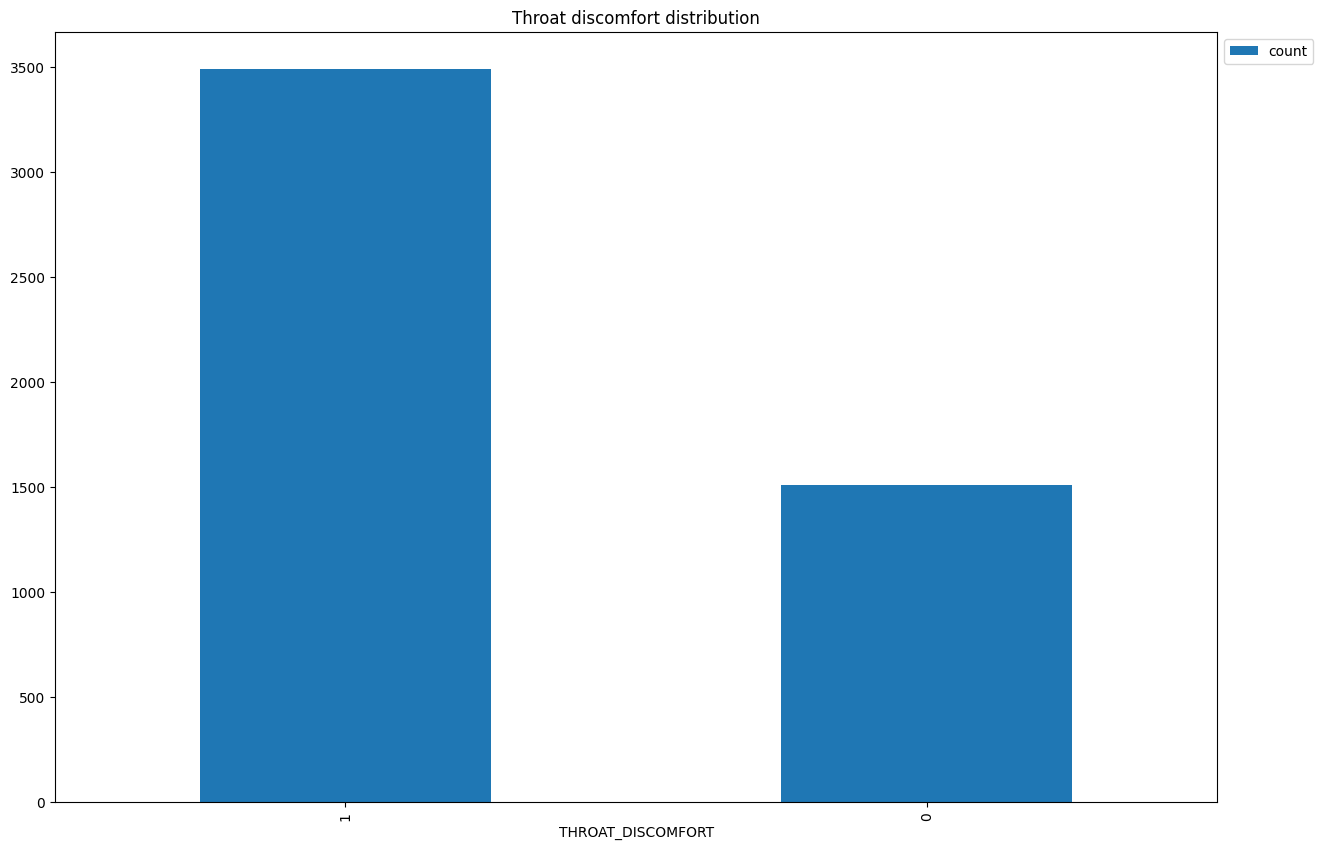

In [141]:
ThrtDisc = X['THROAT_DISCOMFORT'].value_counts().plot(
    kind='bar',
    title="Throat discomfort distribution",
    figsize=(15,10)
)

ThrtDisc.legend(loc='upper left', bbox_to_anchor=(1,1))

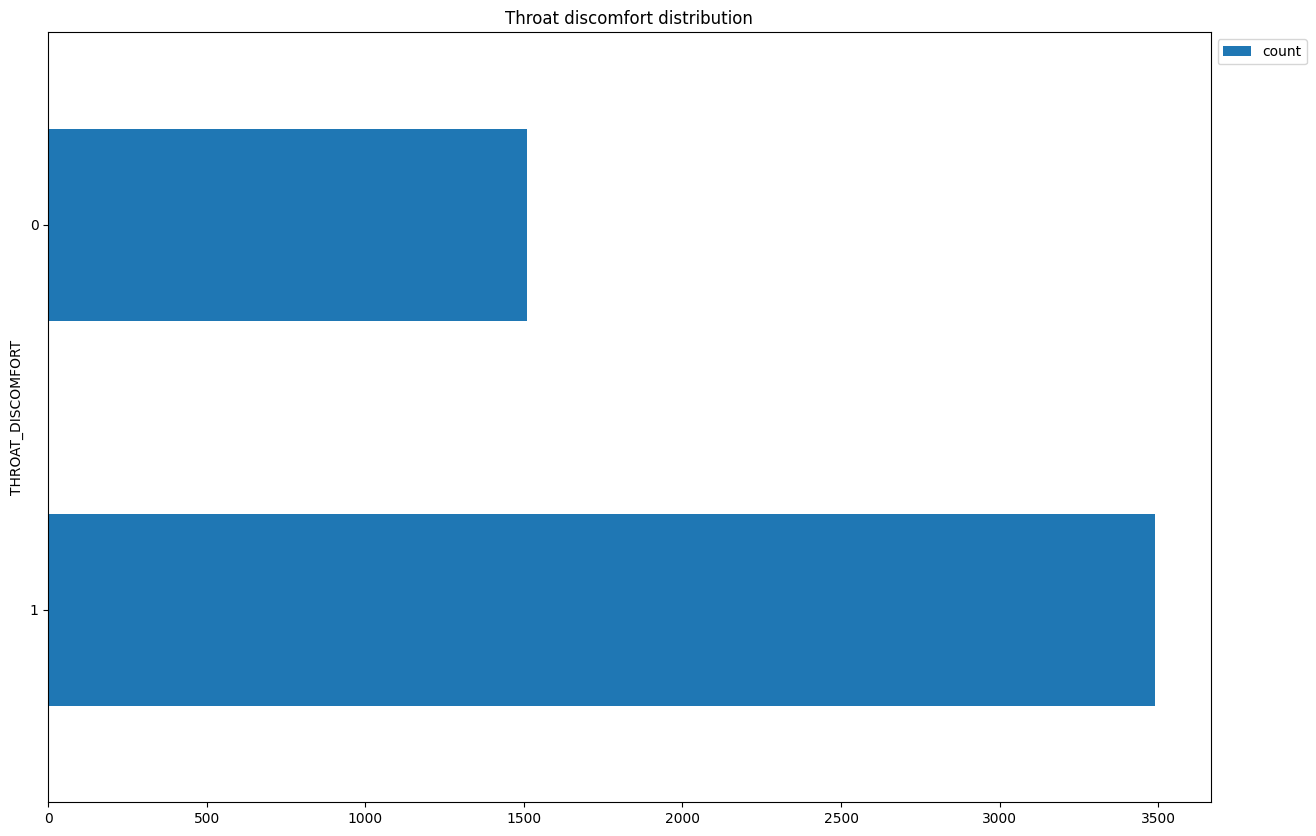

In [142]:
ThrtDisc = X['THROAT_DISCOMFORT'].value_counts().plot(
    kind='barh',
    title="Throat discomfort distribution",
    figsize=(15,10)
)

ThrtDisc.legend(loc='upper left', bbox_to_anchor=(1,1))

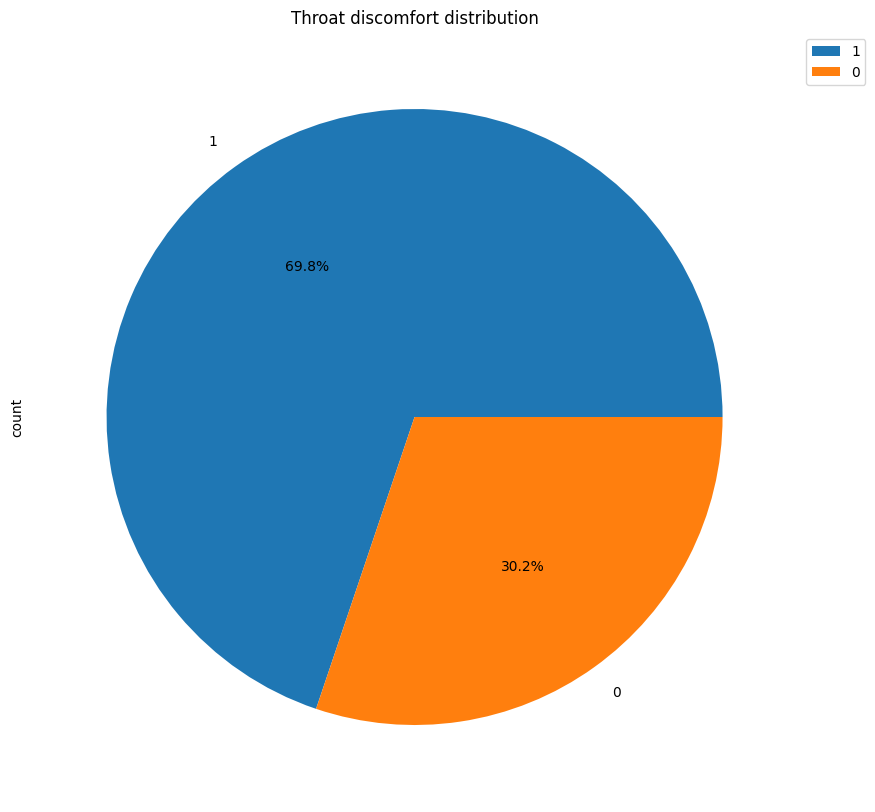

In [143]:
ThrtDisc = X['THROAT_DISCOMFORT'].value_counts().plot(
    kind='pie',
    title="Throat discomfort distribution",
    autopct='%1.1f%%',
    figsize=(15,10)
)

ThrtDisc.legend(loc='upper left', bbox_to_anchor=(1,1))

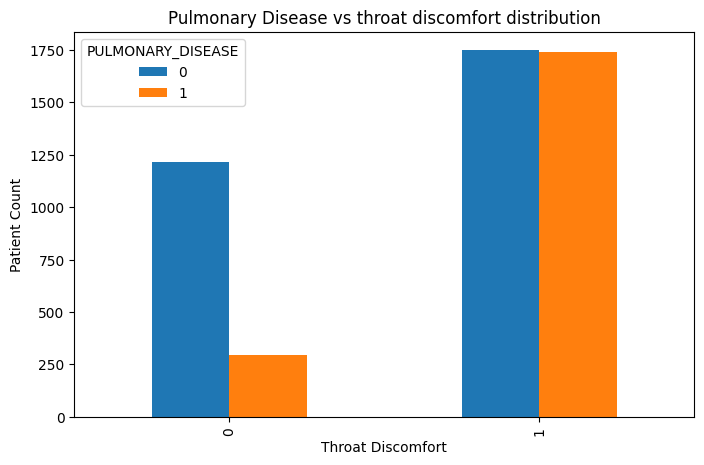

In [144]:
pd.crosstab(
    X['THROAT_DISCOMFORT'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Pulmonary Disease vs throat discomfort distribution")
plt.xlabel("Throat Discomfort")
plt.ylabel("Patient Count")
plt.show()

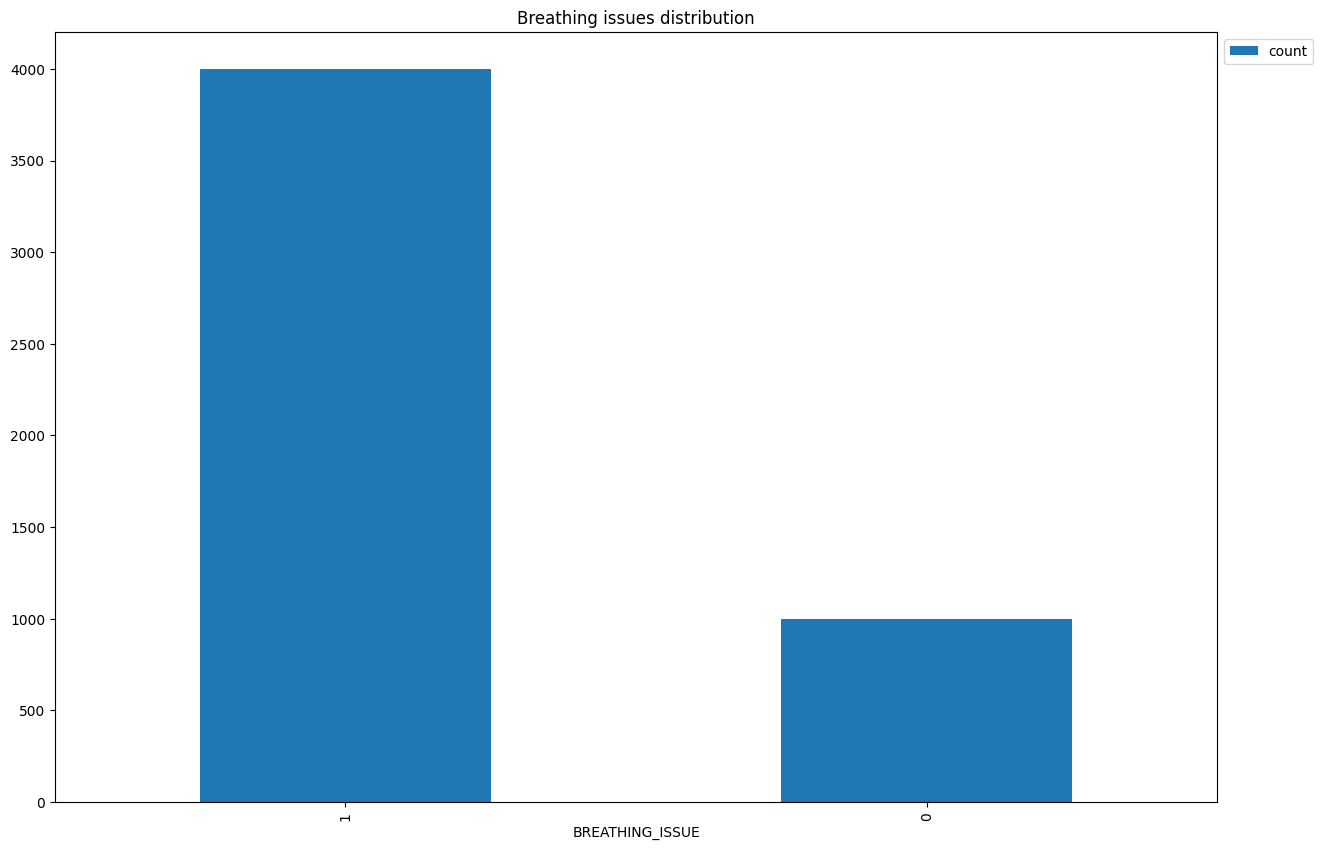

In [145]:
BrthIssue = X['BREATHING_ISSUE'].value_counts().plot(
    kind='bar',
    title="Breathing issues distribution",
    figsize=(15,10)
)

BrthIssue.legend(loc='upper left', bbox_to_anchor=(1,1))

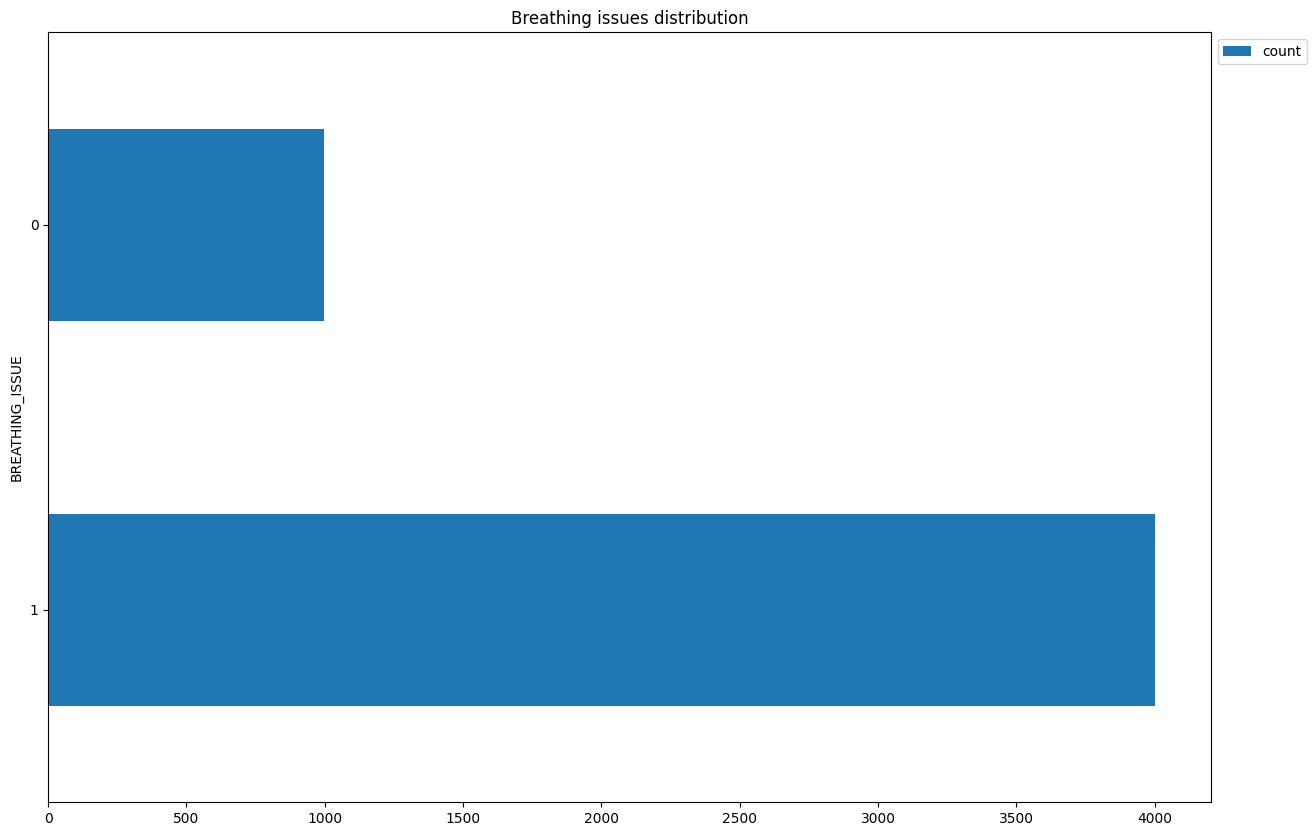

In [146]:
BrthIssue = X['BREATHING_ISSUE'].value_counts().plot(
    kind='barh',
    title="Breathing issues distribution",
    figsize=(15,10)
)

BrthIssue.legend(loc='upper left', bbox_to_anchor=(1,1))

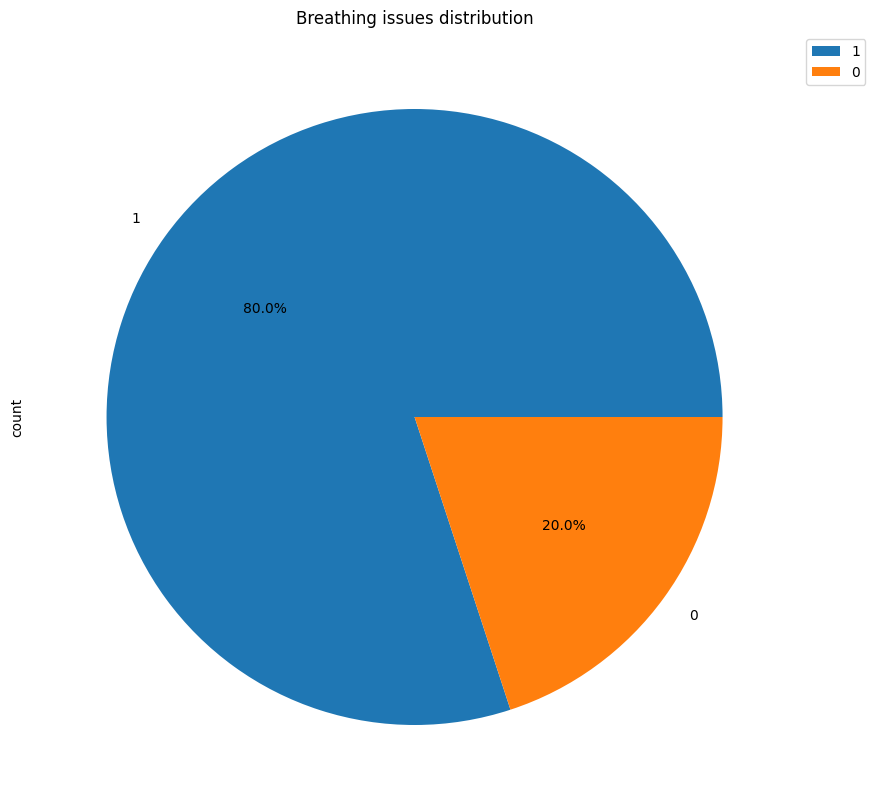

In [147]:
BrthIssue = X['BREATHING_ISSUE'].value_counts().plot(
    kind='pie',
    title="Breathing issues distribution",
    autopct='%1.1f%%',
    figsize=(15,10)
)

BrthIssue.legend(loc='upper left', bbox_to_anchor=(1,1))

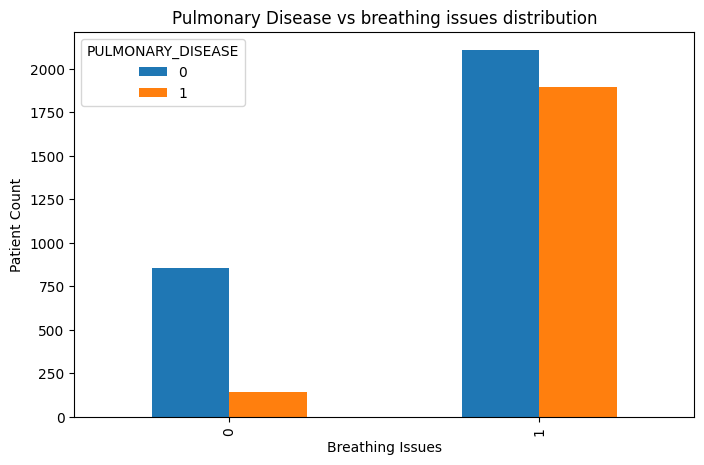

In [148]:
pd.crosstab(
    X['BREATHING_ISSUE'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Pulmonary Disease vs breathing issues distribution")
plt.xlabel("Breathing Issues")
plt.ylabel("Patient Count")
plt.show()

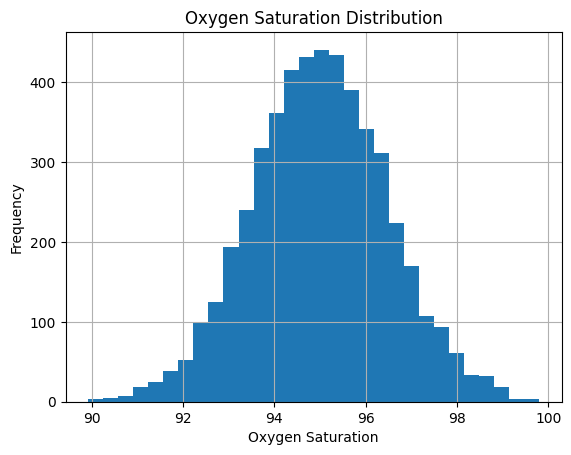

In [149]:
X["OXYGEN_SATURATION"].hist(bins=30)
plt.title("Oxygen Saturation Distribution")
plt.xlabel("Oxygen Saturation")
plt.ylabel("Frequency")
plt.show()

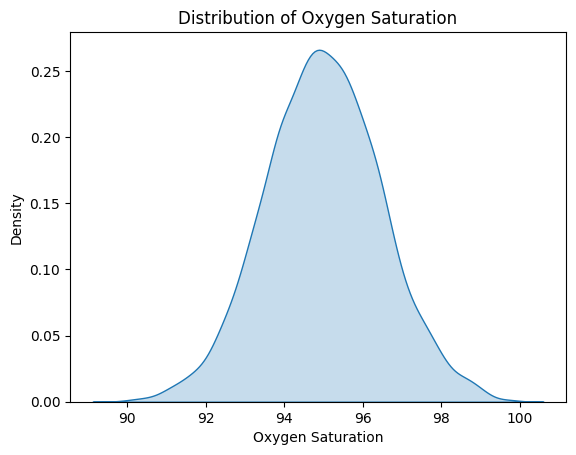

In [150]:
sns.kdeplot(X["OXYGEN_SATURATION"], fill=True)
plt.title("Distribution of Oxygen Saturation")
plt.xlabel("Oxygen Saturation")
plt.ylabel("Density")
plt.show()

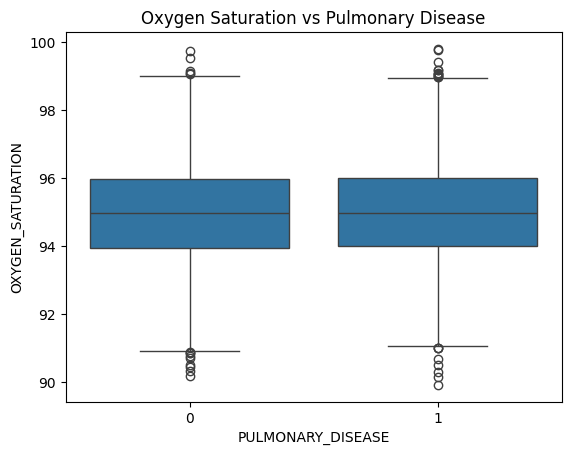

In [151]:
sns.boxplot(x="PULMONARY_DISEASE", y="OXYGEN_SATURATION", data=df)
plt.title("Oxygen Saturation vs Pulmonary Disease")
plt.show()

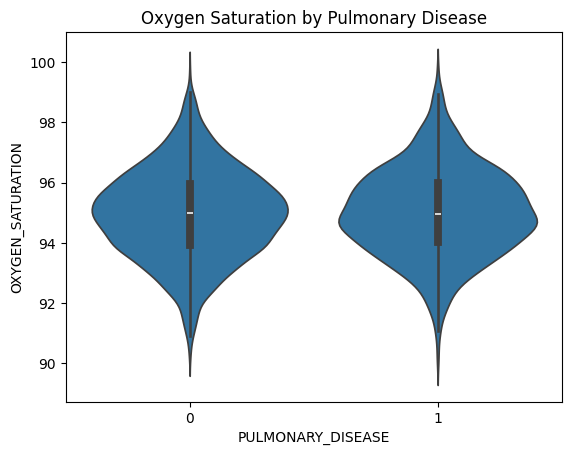

In [152]:
sns.violinplot(x="PULMONARY_DISEASE", y="OXYGEN_SATURATION", data=df)
plt.title("Oxygen Saturation by Pulmonary Disease")
plt.show()

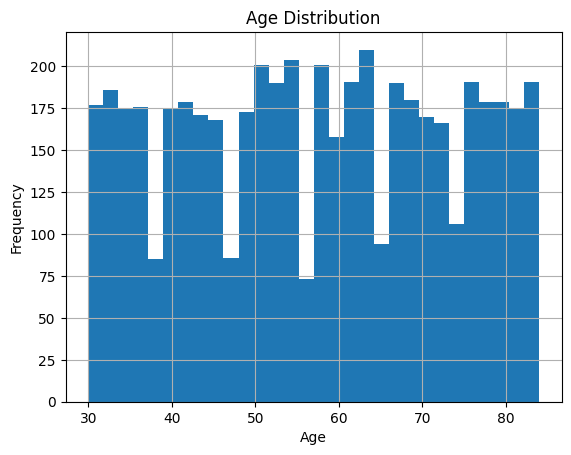

In [153]:
X["AGE"].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

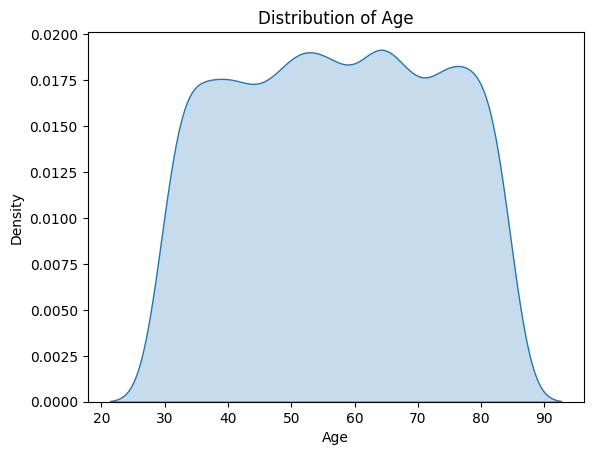

In [154]:
sns.kdeplot(X["AGE"], fill=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

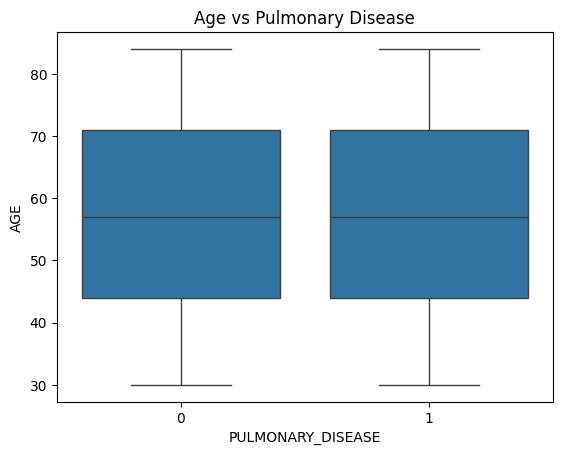

In [155]:
sns.boxplot(x="PULMONARY_DISEASE", y="AGE", data=df)
plt.title("Age vs Pulmonary Disease")
plt.show()

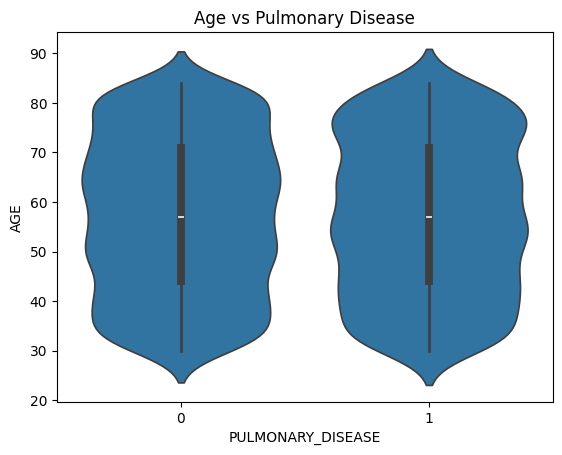

In [156]:
sns.violinplot(x="PULMONARY_DISEASE", y="AGE", data=df)
plt.title("Age vs Pulmonary Disease")
plt.show()

In [ ]:
SmkHist = X['SMOKING_HISTORY_FAMILY'].value_counts().plot(
    kind='bar',
    title="History of family smoking",
    figsize=(15,10)
)

SmkHist.legend(loc='upper left', bbox_to_anchor=(1,1))

In [ ]:
SmkHist = X['SMOKING_HISTORY_FAMILY'].value_counts().plot(
    kind='barh',
    title="History of family smoking",
    figsize=(15,10)
)

SmkHist.legend(loc='upper left', bbox_to_anchor=(1,1))

In [ ]:
SmkHist = X['SMOKING_HISTORY_FAMILY'].value_counts().plot(
    kind='pie',
    title="History of family smoking",
    autopct='%1.1f%%',
    figsize=(15,10)
)

SmkHist.legend(loc='upper left', bbox_to_anchor=(1,1))

In [ ]:
pd.crosstab(
    X['SMOKING_HISTORY_FAMILY'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Pulmonary Disease vs history of family smoking")
plt.xlabel("History of Family Smoking")
plt.ylabel("Patient Count")
plt.show()

In [ ]:
strImm = X['STRESS_IMMUNE'].value_counts().plot(
    kind='bar',
    title="Immune stress distribution",
    figsize=(15,10)
)

strImm.legend(loc='upper left', bbox_to_anchor=(1,1))

In [ ]:
strImm = X['STRESS_IMMUNE'].value_counts().plot(
    kind='barh',
    title="Immune stress distribution",
    figsize=(15,10)
)

strImm.legend(loc='upper left', bbox_to_anchor=(1,1))

In [ ]:
strImm = X['STRESS_IMMUNE'].value_counts().plot(
    kind='pie',
    title="Immune stress distribution",
    autopct='%1.1f%%',
    figsize=(15,10)
)

strImm.legend(loc='upper left', bbox_to_anchor=(1,1))

In [ ]:
pd.crosstab(
    X['STRESS_IMMUNE'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Pulmonary Disease vs immune stress distribution")
plt.xlabel("Immune Stress")
plt.ylabel("Patient Count")
plt.show()

In [ ]:
pollExp = X['EXPOSURE_TO_POLLUTION'].value_counts().plot(
    kind='bar',
    title="Exposure to pollution",
    figsize=(15,10)
)

pollExp.legend(loc='upper left', bbox_to_anchor=(1,1))

In [ ]:
pollExp = X['EXPOSURE_TO_POLLUTION'].value_counts().plot(
    kind='barh',
    title="Exposure to pollution",
    figsize=(15,10)
)

pollExp.legend(loc='upper left', bbox_to_anchor=(1,1))

In [ ]:
strImm = X['EXPOSURE_TO_POLLUTION'].value_counts().plot(
    kind='pie',
    title="Exposure to pollution",
    autopct='%1.1f%%',
    figsize=(15,10)
)

strImm.legend(loc='upper left', bbox_to_anchor=(1,1))

In [ ]:
pd.crosstab(
    X['EXPOSURE_TO_POLLUTION'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Pulmonary Disease vs exposure to pollution")
plt.xlabel("Exposure to Pollution")
plt.ylabel("Patient Count")
plt.show()

In [ ]:
famHist = X['FAMILY_HISTORY'].value_counts().plot(
    kind='bar',
    title="Family history with pulmonary diseases",
    figsize=(15,10)
)

famHist.legend(loc='upper left', bbox_to_anchor=(1,1))

In [ ]:
famHist = X['FAMILY_HISTORY'].value_counts().plot(
    kind='barh',
    title="Family history with pulmonary diseases",
    figsize=(15,10)
)

famHist.legend(loc='upper left', bbox_to_anchor=(1,1))

In [ ]:
strImm = X['FAMILY_HISTORY'].value_counts().plot(
    kind='pie',
    title="Family history with pulmonary diseases",
    autopct='%1.1f%%',
    figsize=(15,10)
)

strImm.legend(loc='upper left', bbox_to_anchor=(1,1))

In [ ]:
pd.crosstab(
    X['FAMILY_HISTORY'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Pulmonary Disease vs family history with pulmonary diseases")
plt.xlabel("Family history with pulmonary diseases")
plt.ylabel("Patient Count")
plt.show()